# EconML Tutorial 04: CausalForestDML

This notebook introduces `CausalForestDML`, EconML's forest-based estimator for heterogeneous treatment effects.

The earlier notebooks focused on linear final-stage CATE models. A linear CATE model is readable, but it can miss nonlinear patterns such as thresholds, saturation, and feature interactions. Causal forests are useful when the causal question is still the same but the heterogeneity surface is more flexible:

> For each unit, how much would the outcome change under treatment, and how does that effect vary across pre-treatment features in a nonlinear way?

This lesson uses simulated data with known nonlinear treatment effects. That gives us a clean teaching loop: fit a causal forest, estimate CATE values and intervals, inspect feature importance, summarize segments, and check whether the forest learns the true effect ranking.

## Learning Goals

By the end of this notebook, you should be able to:

- explain when `CausalForestDML` is preferable to a linear CATE model;
- define `X`, `W`, treatment, and outcome for a causal forest workflow;
- fit `CausalForestDML` with flexible nuisance models;
- compute CATE estimates, ATE estimates, and uncertainty intervals;
- inspect forest feature importance without treating it as a causal assumption check;
- compare causal-forest CATE recovery against a linear DML baseline;
- summarize heterogeneous effects by segments, deciles, and targeted groups;
- diagnose overlap, interval width, support, and ranking quality.

## Why Causal Forests Are Different

`CausalForestDML` still follows the DML idea: nuisance models adjust for baseline outcome and treatment assignment, then a final treatment-effect model estimates heterogeneity.

The key difference is the final CATE model. Instead of estimating one linear equation over `X`, a causal forest estimates local treatment effects by building many honest trees. These trees split the feature space to find regions where treatment effects differ.

Important consequences:

- CATE estimates can be nonlinear in `X`.
- Interactions can be learned without manually writing interaction terms.
- Feature importance replaces a simple coefficient table.
- Estimates can be noisier in small or weak-overlap regions.
- The model is less compact to explain than `LinearDML`, so diagnostics and segment summaries become more important.

## Tutorial Flow

The notebook follows this sequence:

1. Create a nonlinear, confounded, truth-known dataset.
2. Check raw bias, covariate imbalance, and propensity overlap.
3. Define `X` and `W` roles for the forest.
4. Fit a linear DML baseline for comparison.
5. Fit `CausalForestDML` with inference enabled.
6. Compare CATE recovery, ATE error, and ranking quality.
7. Inspect feature importance and nonlinear effect slices.
8. Study uncertainty intervals and interval width drivers.
9. Summarize segment effects and targeting behavior.
10. Close with a practical causal-forest checklist.

## Setup

This cell imports the packages used in the lesson, creates output folders, fixes a random seed, and checks that EconML is available. The warning filters keep the notebook readable while still allowing real execution errors to surface.

In [1]:
from pathlib import Path
import os
import warnings
import importlib.metadata as importlib_metadata

# Keep Matplotlib cache files in a writable location during notebook execution.
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-ranking-sys")

warnings.filterwarnings("default")
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=PendingDeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*IProgress not found.*")
warnings.filterwarnings("ignore", message=".*X does not have valid feature names.*")
warnings.filterwarnings("ignore", message=".*The final model has a nonzero intercept.*")
warnings.filterwarnings("ignore", message=".*Co-variance matrix is underdetermined.*")
warnings.filterwarnings("ignore", module="sklearn.linear_model._logistic")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import brier_score_loss, log_loss, mean_squared_error, roc_auc_score
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_predict, train_test_split

try:
    import econml
    from econml.dml import CausalForestDML, LinearDML
    ECONML_AVAILABLE = True
    ECONML_VERSION = getattr(econml, "__version__", "unknown")
except Exception as exc:
    ECONML_AVAILABLE = False
    ECONML_VERSION = f"import failed: {type(exc).__name__}: {exc}"

RANDOM_SEED = 2026
rng = np.random.default_rng(RANDOM_SEED)

OUTPUT_DIR = Path("outputs")
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 140)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

print(f"EconML available: {ECONML_AVAILABLE}")
print(f"EconML version: {ECONML_VERSION}")
print(f"Figures will be saved to: {FIGURE_DIR.resolve()}")
print(f"Tables will be saved to: {TABLE_DIR.resolve()}")

EconML available: True
EconML version: 0.16.0
Figures will be saved to: /home/apex/Documents/ranking_sys/notebooks/tutorials/econml/outputs/figures
Tables will be saved to: /home/apex/Documents/ranking_sys/notebooks/tutorials/econml/outputs/tables


What this shows: the notebook is ready if EconML imports successfully. The output folders are shared across the EconML tutorial series, with filenames prefixed by `04_` for this lesson.

## Estimator Map

Before generating data, it helps to state what the causal forest is meant to add beyond the previous linear lessons.

In [2]:
estimator_map = pd.DataFrame(
    [
        {
            "estimator": "LinearDML",
            "final CATE model": "Linear function of X",
            "best fit": "Readable effect drivers when heterogeneity is roughly linear",
            "output style": "Coefficients plus unit-level CATE estimates",
            "main limitation": "Can miss thresholds, saturation, and interactions unless manually engineered",
        },
        {
            "estimator": "CausalForestDML",
            "final CATE model": "Forest-based local treatment-effect model",
            "best fit": "Nonlinear heterogeneity, interactions, and segment discovery",
            "output style": "CATE estimates, intervals, feature importance, segment summaries",
            "main limitation": "Less compact than a coefficient table and more sensitive to support in small regions",
        },
    ]
)

estimator_map.to_csv(TABLE_DIR / "04_estimator_map.csv", index=False)
display(estimator_map)

,estimator,final CATE model,best fit,output style,main limitation
0,LinearDML,Linear function of X,Readable effect drivers when heterogeneity is ...,Coefficients plus unit-level CATE estimates,"Can miss thresholds, saturation, and interacti..."
1,CausalForestDML,Forest-based local treatment-effect model,"Nonlinear heterogeneity, interactions, and seg...","CATE estimates, intervals, feature importance,...",Less compact than a coefficient table and more...


What this shows: the causal forest is not a replacement for causal design. It is a more flexible final-stage CATE model inside the same broad DML workflow.

## Nonlinear Teaching Data

The next cell creates a dataset with observed confounding and a nonlinear true treatment effect. The true CATE includes:

- a threshold effect for high baseline need;
- a smooth nonlinear effect of prior engagement;
- a friction penalty that becomes stronger at high friction;
- an interaction between novelty affinity and baseline need;
- a binary segment penalty for region risk.

These patterns are intentionally hard for a simple linear CATE model to capture fully.

In [3]:
n = 3_000

baseline_need = rng.normal(0, 1, size=n)
prior_engagement = rng.normal(0, 1, size=n)
friction_score = 0.50 * baseline_need - 0.25 * prior_engagement + rng.normal(0, 0.85, size=n)
novelty_affinity = rng.normal(0, 1, size=n)
price_sensitivity = rng.normal(0, 1, size=n)
content_depth = 0.40 * prior_engagement + 0.20 * novelty_affinity + rng.normal(0, 0.90, size=n)
recency_gap = rng.normal(0, 1, size=n)
region_risk = rng.binomial(1, 0.36, size=n)
high_need_segment = (baseline_need > 0.60).astype(int)

account_tenure = rng.normal(0, 1, size=n)
seasonality_index = rng.normal(0, 1, size=n)
device_stability = rng.normal(0, 1, size=n)
traffic_intensity = rng.normal(0, 1, size=n)

propensity_logit = (
    -0.12
    + 0.75 * baseline_need
    + 0.42 * prior_engagement
    + 0.38 * friction_score
    + 0.32 * content_depth
    - 0.24 * price_sensitivity
    + 0.26 * region_risk
    + 0.18 * high_need_segment
    - 0.30 * account_tenure
    + 0.24 * seasonality_index
    + 0.16 * traffic_intensity
)
propensity = 1 / (1 + np.exp(-propensity_logit))
propensity = np.clip(propensity, 0.03, 0.97)
treatment = rng.binomial(1, propensity, size=n)

true_cate = (
    0.35
    + 0.42 * high_need_segment
    + 0.24 * np.tanh(prior_engagement)
    - 0.30 * np.maximum(friction_score, 0)
    + 0.22 * novelty_affinity * (baseline_need > 0).astype(float)
    + 0.16 * np.sin(content_depth)
    - 0.18 * region_risk
    - 0.10 * (price_sensitivity > 0.75).astype(float)
)

baseline_outcome = (
    2.25
    + 0.80 * baseline_need
    + 0.62 * prior_engagement
    - 0.55 * friction_score
    + 0.30 * novelty_affinity
    + 0.25 * content_depth
    + 0.36 * account_tenure
    + 0.25 * seasonality_index
    + 0.20 * device_stability
    + 0.18 * traffic_intensity
    + 0.20 * region_risk
    + 0.12 * baseline_need * friction_score
    - 0.12 * price_sensitivity * novelty_affinity
)
noise = rng.normal(0, 0.95, size=n)
outcome = baseline_outcome + true_cate * treatment + noise

teaching_df = pd.DataFrame(
    {
        "user_id": np.arange(n),
        "baseline_need": baseline_need,
        "prior_engagement": prior_engagement,
        "friction_score": friction_score,
        "novelty_affinity": novelty_affinity,
        "price_sensitivity": price_sensitivity,
        "content_depth": content_depth,
        "recency_gap": recency_gap,
        "region_risk": region_risk,
        "high_need_segment": high_need_segment,
        "account_tenure": account_tenure,
        "seasonality_index": seasonality_index,
        "device_stability": device_stability,
        "traffic_intensity": traffic_intensity,
        "propensity": propensity,
        "treatment": treatment,
        "outcome": outcome,
        "true_cate": true_cate,
        "baseline_outcome_mean": baseline_outcome,
    }
)

teaching_df.head()

,user_id,baseline_need,prior_engagement,friction_score,novelty_affinity,price_sensitivity,content_depth,recency_gap,region_risk,high_need_segment,account_tenure,seasonality_index,device_stability,traffic_intensity,propensity,treatment,outcome,true_cate,baseline_outcome_mean
0,0,-0.7931,-0.4520,0.0233,1.5171,1.4847,0.6575,1.6834,0,0,-0.3757,-1.0499,-0.0713,1.7041,0.2873,0,1.6014,0.2392,1.5642
1,1,0.2406,-0.3531,-0.7239,-0.6711,-1.7368,0.9496,-1.4981,1,0,0.0106,-1.5990,-0.4807,2.2731,0.6444,1,3.7779,0.0711,2.6141
2,2,-1.8963,-0.9423,-1.1321,0.9219,0.9344,0.9479,2.8652,1,0,1.6226,0.3719,-1.0464,-1.3406,0.0665,0,2.5904,0.0232,1.8656
3,3,1.3958,0.0110,1.1108,0.1365,0.2148,0.6279,-0.2507,1,1,-1.5408,-1.8431,0.3545,0.7243,0.8888,1,5.5823,0.3834,2.5288
4,4,0.6383,1.1904,-0.4781,1.5456,-0.3884,0.8293,-1.8590,1,1,-0.5915,-0.6628,0.1159,-0.8280,0.7960,1,4.0635,1.2474,4.1636


What this shows: we now have a CATE surface with thresholds, smooth nonlinear terms, and interactions. A causal forest should have an advantage over a purely linear final-stage model in this setting.

## Field Dictionary

A data dictionary prevents leakage and clarifies feature roles. The oracle columns are included only because this is a simulation; they must not be used as model inputs.

In [4]:
effect_modifier_cols = [
    "baseline_need",
    "prior_engagement",
    "friction_score",
    "novelty_affinity",
    "price_sensitivity",
    "content_depth",
    "recency_gap",
    "region_risk",
    "high_need_segment",
]
control_cols = ["account_tenure", "seasonality_index", "device_stability", "traffic_intensity"]
all_observed_covariates = effect_modifier_cols + control_cols
true_driver_cols = [
    "baseline_need",
    "prior_engagement",
    "friction_score",
    "novelty_affinity",
    "price_sensitivity",
    "content_depth",
    "region_risk",
    "high_need_segment",
]

field_rows = []
for col in effect_modifier_cols:
    field_rows.append(
        {
            "column": col,
            "role": "X effect modifier",
            "observed_in_real_analysis": "yes",
            "description": "Pre-treatment feature allowed to shape the forest CATE function.",
            "true_cate_driver": "yes" if col in true_driver_cols else "no",
        }
    )
for col in control_cols:
    field_rows.append(
        {
            "column": col,
            "role": "W control",
            "observed_in_real_analysis": "yes",
            "description": "Pre-treatment adjustment feature used in nuisance models.",
            "true_cate_driver": "no",
        }
    )
for col, role, description in [
    ("treatment", "treatment", "Binary intervention indicator."),
    ("outcome", "outcome", "Observed post-treatment outcome."),
    ("propensity", "oracle", "True treatment probability from the simulated assignment process."),
    ("true_cate", "oracle", "Known individual treatment effect used only for tutorial evaluation."),
    ("baseline_outcome_mean", "oracle", "Mean untreated outcome component before random noise."),
]:
    field_rows.append(
        {
            "column": col,
            "role": role,
            "observed_in_real_analysis": "yes" if role in ["treatment", "outcome"] else "no",
            "description": description,
            "true_cate_driver": "not applicable",
        }
    )

field_dictionary = pd.DataFrame(field_rows)
field_dictionary.to_csv(TABLE_DIR / "04_field_dictionary.csv", index=False)
display(field_dictionary)

,column,role,observed_in_real_analysis,description,true_cate_driver
0,baseline_need,X effect modifier,yes,Pre-treatment feature allowed to shape the for...,yes
1,prior_engagement,X effect modifier,yes,Pre-treatment feature allowed to shape the for...,yes
2,friction_score,X effect modifier,yes,Pre-treatment feature allowed to shape the for...,yes
3,novelty_affinity,X effect modifier,yes,Pre-treatment feature allowed to shape the for...,yes
4,price_sensitivity,X effect modifier,yes,Pre-treatment feature allowed to shape the for...,yes
5,content_depth,X effect modifier,yes,Pre-treatment feature allowed to shape the for...,yes
6,recency_gap,X effect modifier,yes,Pre-treatment feature allowed to shape the for...,no
7,region_risk,X effect modifier,yes,Pre-treatment feature allowed to shape the for...,yes
8,high_need_segment,X effect modifier,yes,Pre-treatment feature allowed to shape the for...,yes
9,account_tenure,W control,yes,Pre-treatment adjustment feature used in nuisa...,no


What this shows: the forest gets one intentionally irrelevant effect modifier, `recency_gap`, plus several true drivers. Feature importance later should help separate the stronger CATE drivers from weaker or irrelevant dimensions.

## Basic Shape And True Effect Scale

This summary tells us how large the dataset is, how common treatment is, and how much true treatment-effect variation exists.

In [5]:
basic_summary = pd.DataFrame(
    [
        {"metric": "rows", "value": len(teaching_df)},
        {"metric": "columns", "value": teaching_df.shape[1]},
        {"metric": "X_effect_modifiers", "value": len(effect_modifier_cols)},
        {"metric": "W_controls", "value": len(control_cols)},
        {"metric": "treatment_rate", "value": teaching_df["treatment"].mean()},
        {"metric": "outcome_mean", "value": teaching_df["outcome"].mean()},
        {"metric": "true_ate", "value": teaching_df["true_cate"].mean()},
        {"metric": "true_cate_std", "value": teaching_df["true_cate"].std()},
        {"metric": "true_cate_min", "value": teaching_df["true_cate"].min()},
        {"metric": "true_cate_max", "value": teaching_df["true_cate"].max()},
    ]
)

basic_summary.to_csv(TABLE_DIR / "04_basic_summary.csv", index=False)
display(basic_summary)

,metric,value
0,rows,"3,000.0000"
1,columns,19.0000
2,X_effect_modifiers,9.0000
3,W_controls,4.0000
4,treatment_rate,0.5017
5,outcome_mean,2.5335
6,true_ate,0.2662
7,true_cate_std,0.3710
8,true_cate_min,-1.1526
9,true_cate_max,1.5238


What this shows: there is meaningful CATE variation and the treatment rate is not extreme. That makes the dataset appropriate for a causal-forest teaching example.

## True CATE Distribution

Before fitting a model, we visualize the true treatment-effect distribution. In real data this plot is impossible, but it is useful here because the simulation lets us see what the model is trying to recover.

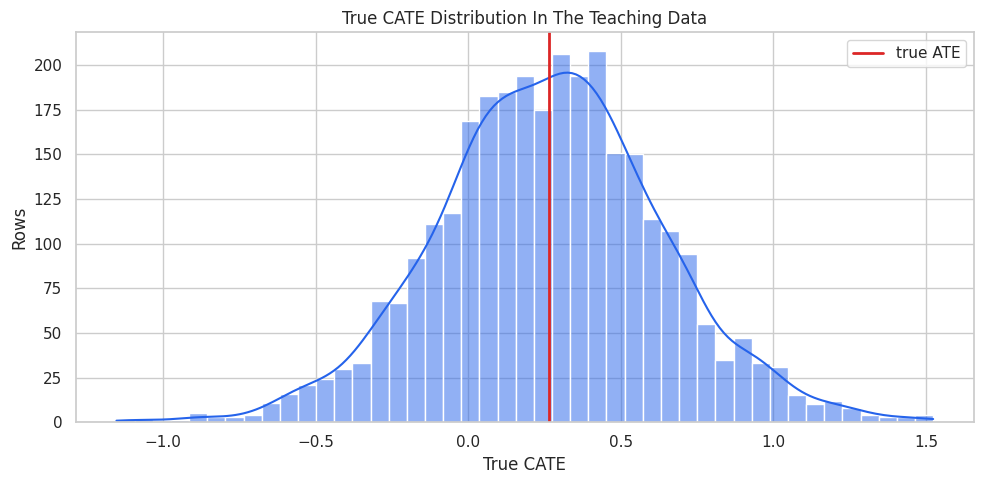

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(teaching_df["true_cate"], bins=45, kde=True, color="#2563eb", ax=ax)
ax.axvline(teaching_df["true_cate"].mean(), color="#dc2626", linewidth=2, label="true ATE")
ax.set_title("True CATE Distribution In The Teaching Data")
ax.set_xlabel("True CATE")
ax.set_ylabel("Rows")
ax.legend()
plt.tight_layout()
fig.savefig(FIGURE_DIR / "04_true_cate_distribution.png", dpi=160, bbox_inches="tight")
plt.show()

What this shows: the effect distribution includes both high-benefit and lower-benefit units. A useful CATE model should rank those units well, not merely estimate one average effect.

## Raw Treated-Versus-Control Difference

A raw outcome difference is a useful warning label. It shows what we would get if we ignored confounding and heterogeneity.

In [7]:
raw_group_summary = (
    teaching_df.groupby("treatment")
    .agg(
        rows=("outcome", "size"),
        observed_outcome_mean=("outcome", "mean"),
        true_cate_mean=("true_cate", "mean"),
        propensity_mean=("propensity", "mean"),
        baseline_need_mean=("baseline_need", "mean"),
        friction_score_mean=("friction_score", "mean"),
        content_depth_mean=("content_depth", "mean"),
    )
    .reset_index()
)
raw_difference = (
    raw_group_summary.loc[raw_group_summary["treatment"].eq(1), "observed_outcome_mean"].iloc[0]
    - raw_group_summary.loc[raw_group_summary["treatment"].eq(0), "observed_outcome_mean"].iloc[0]
)
true_ate = teaching_df["true_cate"].mean()

raw_difference_summary = pd.DataFrame(
    [
        {"quantity": "raw treated minus untreated outcome mean", "value": raw_difference},
        {"quantity": "true ATE", "value": true_ate},
        {"quantity": "raw difference minus true ATE", "value": raw_difference - true_ate},
    ]
)

raw_group_summary.to_csv(TABLE_DIR / "04_raw_group_summary.csv", index=False)
raw_difference_summary.to_csv(TABLE_DIR / "04_raw_difference_vs_truth.csv", index=False)
display(raw_group_summary)
display(raw_difference_summary)

,treatment,rows,observed_outcome_mean,true_cate_mean,propensity_mean,baseline_need_mean,friction_score_mean,content_depth_mean
0,0,1495,2.0510,0.2055,0.3756,-0.4127,-0.2952,-0.1534
1,1,1505,3.0128,0.3266,0.6214,0.3506,0.2443,0.1975


,quantity,value
0,raw treated minus untreated outcome mean,0.9618
1,true ATE,0.2662
2,raw difference minus true ATE,0.6956


What this shows: treated and untreated rows differ in observed covariates and in average true CATE. This is why a flexible CATE model still needs careful nuisance adjustment.

## Covariate Balance Table

The standardized mean difference measures pre-treatment imbalance. Large absolute values mean treated and untreated rows differ before treatment.

In [8]:
balance_rows = []
for col in all_observed_covariates:
    treated_values = teaching_df.loc[teaching_df["treatment"].eq(1), col]
    control_values = teaching_df.loc[teaching_df["treatment"].eq(0), col]
    pooled_sd = np.sqrt((treated_values.var(ddof=1) + control_values.var(ddof=1)) / 2)
    balance_rows.append(
        {
            "covariate": col,
            "treated_mean": treated_values.mean(),
            "control_mean": control_values.mean(),
            "standardized_difference": (treated_values.mean() - control_values.mean()) / pooled_sd,
        }
    )

balance_table = pd.DataFrame(balance_rows).sort_values("standardized_difference", key=lambda s: s.abs(), ascending=False)
balance_table.to_csv(TABLE_DIR / "04_covariate_balance.csv", index=False)
display(balance_table)

,covariate,treated_mean,control_mean,standardized_difference
0,baseline_need,0.3506,-0.4127,0.8151
8,high_need_segment,0.4066,0.1398,0.6274
2,friction_score,0.2443,-0.2952,0.5488
5,content_depth,0.1975,-0.1534,0.3531
1,prior_engagement,0.1905,-0.1354,0.3300
9,account_tenure,-0.1221,0.1434,-0.2616
12,traffic_intensity,0.0988,-0.0778,0.1787
4,price_sensitivity,-0.0872,0.0593,-0.1481
10,seasonality_index,0.0257,-0.0811,0.1095
7,region_risk,0.3701,0.3284,0.0875


What this shows: the treatment process is observably confounded. A causal forest estimates heterogeneous effects after DML adjustment; it is not just a predictive forest on raw outcomes.

## Covariate Balance Plot

This plot highlights the most imbalanced pre-treatment features. It is a quick visual diagnostic of why adjustment is necessary.

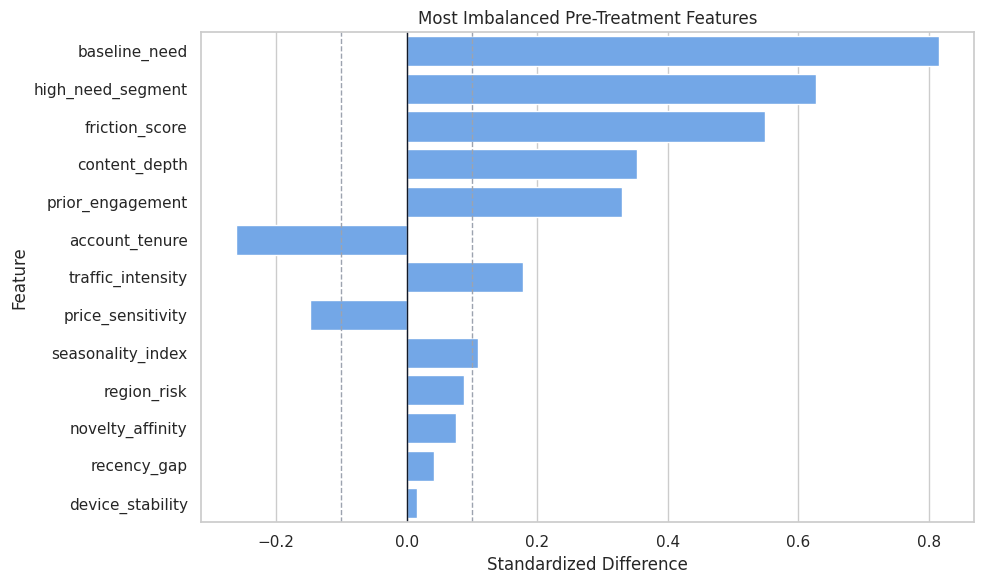

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=balance_table.head(13),
    x="standardized_difference",
    y="covariate",
    color="#60a5fa",
    ax=ax,
)
ax.axvline(0, color="#111827", linewidth=1)
ax.axvline(0.10, color="#9ca3af", linewidth=1, linestyle="--")
ax.axvline(-0.10, color="#9ca3af", linewidth=1, linestyle="--")
ax.set_title("Most Imbalanced Pre-Treatment Features")
ax.set_xlabel("Standardized Difference")
ax.set_ylabel("Feature")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "04_covariate_balance.png", dpi=160, bbox_inches="tight")
plt.show()

What this shows: several CATE-relevant features are also treatment-assignment predictors. That makes the combination of DML adjustment and flexible heterogeneity modeling useful.

## Propensity Overlap

Overlap means comparable units have some chance of being treated and some chance of being untreated. Causal forests can become unstable in regions with weak overlap because the model has little local contrast to learn from.

In [10]:
propensity_summary = (
    teaching_df.assign(propensity_bucket=pd.cut(teaching_df["propensity"], bins=np.linspace(0, 1, 11), include_lowest=True))
    .groupby("propensity_bucket", observed=True)
    .agg(
        rows=("propensity", "size"),
        treatment_rate=("treatment", "mean"),
        true_cate_mean=("true_cate", "mean"),
        baseline_need_mean=("baseline_need", "mean"),
    )
    .reset_index()
)
propensity_summary["propensity_bucket"] = propensity_summary["propensity_bucket"].astype(str)
propensity_summary.to_csv(TABLE_DIR / "04_propensity_bucket_summary.csv", index=False)
display(propensity_summary)

,propensity_bucket,rows,treatment_rate,true_cate_mean,baseline_need_mean
0,"(-0.001, 0.1]",101,0.0495,0.0832,-1.7167
1,"(0.1, 0.2]",321,0.1402,0.1135,-1.1302
2,"(0.2, 0.3]",337,0.2404,0.1343,-0.6621
3,"(0.3, 0.4]",366,0.3415,0.1717,-0.4287
4,"(0.4, 0.5]",390,0.4718,0.1999,-0.1900
5,"(0.5, 0.6]",386,0.5415,0.2752,0.0554
6,"(0.6, 0.7]",357,0.6863,0.3596,0.3716
7,"(0.7, 0.8]",302,0.7351,0.3948,0.6606
8,"(0.8, 0.9]",319,0.8589,0.4815,1.0810
9,"(0.9, 1.0]",121,0.9504,0.4983,1.6738


What this shows: most observations are in non-extreme propensity regions, which is helpful. The bucket summary also shows that propensity regions differ in average true effect, which makes naive comparisons especially risky.

## Propensity Overlap Plot

The histogram below shows the true propensity distribution by observed treatment group. In real data, this would be based on an estimated propensity model.

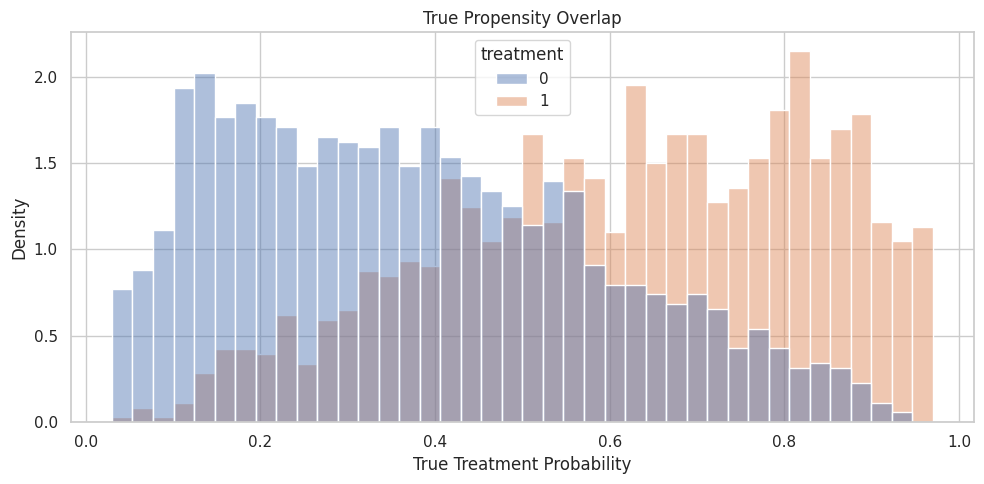

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(
    data=teaching_df,
    x="propensity",
    hue="treatment",
    bins=40,
    stat="density",
    common_norm=False,
    alpha=0.45,
    ax=ax,
)
ax.set_title("True Propensity Overlap")
ax.set_xlabel("True Treatment Probability")
ax.set_ylabel("Density")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "04_propensity_overlap.png", dpi=160, bbox_inches="tight")
plt.show()

What this shows: the groups overlap but are shifted. That is a good teaching case: enough support for estimation, but enough confounding that raw comparisons are not credible.

## X And W Roles

For `CausalForestDML`, `X` contains the features that define the CATE surface. The forest splits over `X` to find regions with different treatment effects.

`W` contains additional pre-treatment controls used in nuisance models. These controls help adjust for confounding but are not used as the main axes of the final forest CATE surface.

In [12]:
role_table = pd.DataFrame(
    [
        {
            "feature": col,
            "econml_role": "X",
            "true_cate_driver": col in true_driver_cols,
            "reason": "Candidate effect modifier used by the causal forest CATE model.",
        }
        for col in effect_modifier_cols
    ]
    + [
        {
            "feature": col,
            "econml_role": "W",
            "true_cate_driver": False,
            "reason": "Adjustment control used by nuisance models.",
        }
        for col in control_cols
    ]
)

role_table.to_csv(TABLE_DIR / "04_x_w_role_table.csv", index=False)
display(role_table)

,feature,econml_role,true_cate_driver,reason
0,baseline_need,X,True,Candidate effect modifier used by the causal f...
1,prior_engagement,X,True,Candidate effect modifier used by the causal f...
2,friction_score,X,True,Candidate effect modifier used by the causal f...
3,novelty_affinity,X,True,Candidate effect modifier used by the causal f...
4,price_sensitivity,X,True,Candidate effect modifier used by the causal f...
5,content_depth,X,True,Candidate effect modifier used by the causal f...
6,recency_gap,X,False,Candidate effect modifier used by the causal f...
7,region_risk,X,True,Candidate effect modifier used by the causal f...
8,high_need_segment,X,True,Candidate effect modifier used by the causal f...
9,account_tenure,W,False,Adjustment control used by nuisance models.


What this shows: choosing `X` is a substantive decision. The forest cannot discover heterogeneity along a feature that is excluded from `X`, even if that feature is included in `W` for adjustment.

## Train And Test Split

The train set is used for model fitting. The test set is used for truth-known checks of CATE recovery, ranking, and interval behavior.

In [13]:
train_idx, test_idx = train_test_split(
    teaching_df.index,
    test_size=0.35,
    random_state=RANDOM_SEED,
    stratify=teaching_df["treatment"],
)

train_df = teaching_df.loc[train_idx].reset_index(drop=True)
test_df = teaching_df.loc[test_idx].reset_index(drop=True)

split_summary = pd.DataFrame(
    [
        {"split": "train", "rows": len(train_df), "treatment_rate": train_df["treatment"].mean(), "true_ate": train_df["true_cate"].mean()},
        {"split": "test", "rows": len(test_df), "treatment_rate": test_df["treatment"].mean(), "true_ate": test_df["true_cate"].mean()},
    ]
)

split_summary.to_csv(TABLE_DIR / "04_train_test_split_summary.csv", index=False)
display(split_summary)

,split,rows,treatment_rate,true_ate
0,train,1950,0.5015,0.2699
1,test,1050,0.5019,0.2594


What this shows: treatment balance and true ATE are similar across train and test, so the estimator comparison is not driven by an unusual split.

## Modeling Matrices

This cell creates the data objects passed to EconML. Oracle fields stay out of all model inputs.

In [14]:
Y_train = train_df["outcome"].to_numpy()
T_train = train_df["treatment"].to_numpy()
Y_test = test_df["outcome"].to_numpy()
T_test = test_df["treatment"].to_numpy()

X_train = train_df[effect_modifier_cols]
X_test = test_df[effect_modifier_cols]
W_train = train_df[control_cols]
W_test = test_df[control_cols]

nuisance_train = train_df[all_observed_covariates]
nuisance_test = test_df[all_observed_covariates]
true_cate_train = train_df["true_cate"].to_numpy()
true_cate_test = test_df["true_cate"].to_numpy()

matrix_summary = pd.DataFrame(
    [
        {"object": "Y_train", "rows": Y_train.shape[0], "columns": 1, "meaning": "Observed outcome."},
        {"object": "T_train", "rows": T_train.shape[0], "columns": 1, "meaning": "Observed binary treatment."},
        {"object": "X_train", "rows": X_train.shape[0], "columns": X_train.shape[1], "meaning": "Effect modifiers used by the causal forest."},
        {"object": "W_train", "rows": W_train.shape[0], "columns": W_train.shape[1], "meaning": "Controls used for nuisance adjustment."},
        {"object": "nuisance_train", "rows": nuisance_train.shape[0], "columns": nuisance_train.shape[1], "meaning": "Observed pre-treatment features used for separate nuisance diagnostics."},
    ]
)

matrix_summary.to_csv(TABLE_DIR / "04_model_matrix_summary.csv", index=False)
display(matrix_summary)

,object,rows,columns,meaning
0,Y_train,1950,1,Observed outcome.
1,T_train,1950,1,Observed binary treatment.
2,X_train,1950,9,Effect modifiers used by the causal forest.
3,W_train,1950,4,Controls used for nuisance adjustment.
4,nuisance_train,1950,13,Observed pre-treatment features used for separ...


What this shows: the forest receives a compact set of effect modifiers. The nuisance models still receive enough pre-treatment information to adjust for treatment assignment and baseline outcome structure.

## Separate Nuisance Diagnostics

EconML fits nuisance models internally, but a separate out-of-fold diagnostic pass helps us understand the assignment and outcome prediction problem.

In [15]:
outcome_probe = RandomForestRegressor(
    n_estimators=120,
    min_samples_leaf=20,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
treatment_probe = RandomForestClassifier(
    n_estimators=120,
    min_samples_leaf=20,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

outcome_cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
treatment_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
Y_hat_oof = cross_val_predict(outcome_probe, nuisance_train, Y_train, cv=outcome_cv, method="predict")
T_hat_oof = cross_val_predict(treatment_probe, nuisance_train, T_train, cv=treatment_cv, method="predict_proba")[:, 1]

nuisance_diagnostics = pd.DataFrame(
    [
        {"nuisance_model": "outcome E[Y | X, W]", "metric": "out_of_fold_rmse", "value": np.sqrt(mean_squared_error(Y_train, Y_hat_oof))},
        {"nuisance_model": "treatment E[T | X, W]", "metric": "out_of_fold_auc", "value": roc_auc_score(T_train, T_hat_oof)},
        {"nuisance_model": "treatment E[T | X, W]", "metric": "out_of_fold_brier_score", "value": brier_score_loss(T_train, T_hat_oof)},
        {"nuisance_model": "treatment E[T | X, W]", "metric": "out_of_fold_log_loss", "value": log_loss(T_train, T_hat_oof)},
    ]
)

nuisance_diagnostics.to_csv(TABLE_DIR / "04_nuisance_diagnostics.csv", index=False)
display(nuisance_diagnostics)

,nuisance_model,metric,value
0,"outcome E[Y | X, W]",out_of_fold_rmse,1.2321
1,"treatment E[T | X, W]",out_of_fold_auc,0.7652
2,"treatment E[T | X, W]",out_of_fold_brier_score,0.1981
3,"treatment E[T | X, W]",out_of_fold_log_loss,0.5797


What this shows: treatment is predictable from covariates, which confirms observed confounding. The outcome nuisance model also has meaningful predictive structure to remove before the final CATE stage.

## Fit A LinearDML Baseline

A baseline model makes the causal forest easier to judge. Since the true CATE is nonlinear, a linear final-stage model should be useful but limited.

In [16]:
if not ECONML_AVAILABLE:
    raise ImportError(f"EconML is not available in this environment: {ECONML_VERSION}")

linear_dml = LinearDML(
    model_y=RandomForestRegressor(n_estimators=120, min_samples_leaf=20, random_state=RANDOM_SEED, n_jobs=-1),
    model_t=RandomForestClassifier(n_estimators=120, min_samples_leaf=20, random_state=RANDOM_SEED, n_jobs=-1),
    discrete_treatment=True,
    fit_cate_intercept=True,
    cv=5,
    random_state=RANDOM_SEED,
)
linear_dml.fit(Y_train, T_train, X=X_train, W=W_train, inference=None)
linear_cate_test = np.ravel(linear_dml.effect(X_test))

linear_summary = pd.DataFrame(
    [
        {"metric": "test_estimated_ate", "value": linear_cate_test.mean()},
        {"metric": "test_true_ate", "value": true_cate_test.mean()},
        {"metric": "test_ate_error", "value": linear_cate_test.mean() - true_cate_test.mean()},
        {"metric": "test_cate_rmse", "value": np.sqrt(mean_squared_error(true_cate_test, linear_cate_test))},
        {"metric": "test_cate_correlation", "value": np.corrcoef(true_cate_test, linear_cate_test)[0, 1]},
        {"metric": "test_cate_spearman", "value": pd.Series(linear_cate_test).corr(pd.Series(true_cate_test), method="spearman")},
    ]
)

linear_summary.to_csv(TABLE_DIR / "04_lineardml_baseline_summary.csv", index=False)
display(linear_summary)

,metric,value
0,test_estimated_ate,0.2992
1,test_true_ate,0.2594
2,test_ate_error,0.0398
3,test_cate_rmse,0.3398
4,test_cate_correlation,0.6580
5,test_cate_spearman,0.6415


What this shows: the linear baseline gives us a reference point. If the causal forest is useful here, it should improve CATE recovery or ranking because the true effect surface is nonlinear.

## Fit CausalForestDML

Now we fit the causal forest. Key parameters in this teaching setup:

- `n_estimators`: number of trees; more trees reduce Monte Carlo noise.
- `min_samples_leaf`: minimum local sample size in leaves; larger values smooth estimates.
- `max_samples`: subsample fraction for honest forests; must stay below 0.5 when inference is enabled.
- `honest=True`: separates splitting and estimation samples within trees.
- `inference=True`: enables effect and ATE intervals.

In [17]:
causal_forest = CausalForestDML(
    model_y=RandomForestRegressor(n_estimators=140, min_samples_leaf=20, random_state=RANDOM_SEED + 1, n_jobs=-1),
    model_t=RandomForestClassifier(n_estimators=140, min_samples_leaf=20, random_state=RANDOM_SEED + 1, n_jobs=-1),
    discrete_treatment=True,
    cv=5,
    n_estimators=240,
    min_samples_leaf=18,
    max_depth=None,
    max_samples=0.45,
    honest=True,
    inference=True,
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

causal_forest.fit(Y_train, T_train, X=X_train, W=W_train)
forest_cate_test = np.ravel(causal_forest.effect(X_test))
forest_cate_train = np.ravel(causal_forest.effect(X_train))
forest_lower_test, forest_upper_test = causal_forest.effect_interval(X_test, alpha=0.05)
forest_lower_test = np.ravel(forest_lower_test)
forest_upper_test = np.ravel(forest_upper_test)

forest_ate_test = float(causal_forest.ate(X=X_test))
forest_ate_lower, forest_ate_upper = causal_forest.ate_interval(X=X_test, alpha=0.05)

forest_summary = pd.DataFrame(
    [
        {"metric": "test_estimated_ate", "value": forest_cate_test.mean()},
        {"metric": "test_ate_from_estimator", "value": forest_ate_test},
        {"metric": "test_true_ate", "value": true_cate_test.mean()},
        {"metric": "test_ate_error", "value": forest_cate_test.mean() - true_cate_test.mean()},
        {"metric": "test_ate_interval_lower", "value": float(forest_ate_lower)},
        {"metric": "test_ate_interval_upper", "value": float(forest_ate_upper)},
        {"metric": "test_cate_rmse", "value": np.sqrt(mean_squared_error(true_cate_test, forest_cate_test))},
        {"metric": "test_cate_correlation", "value": np.corrcoef(true_cate_test, forest_cate_test)[0, 1]},
        {"metric": "test_cate_spearman", "value": pd.Series(forest_cate_test).corr(pd.Series(true_cate_test), method="spearman")},
    ]
)

forest_summary.to_csv(TABLE_DIR / "04_causalforestdml_summary.csv", index=False)
display(forest_summary)

,metric,value
0,test_estimated_ate,0.2461
1,test_ate_from_estimator,0.2461
2,test_true_ate,0.2594
3,test_ate_error,-0.0132
4,test_ate_interval_lower,-0.0527
5,test_ate_interval_upper,0.5449
6,test_cate_rmse,0.2735
7,test_cate_correlation,0.6671
8,test_cate_spearman,0.6555


What this shows: `CausalForestDML` returns unit-level CATE estimates and uncertainty intervals. The ATE from the estimator and the mean of unit-level CATE estimates should be close but are reported separately for clarity.

## Compare Linear And Forest Metrics

The next table compares the raw difference, the linear DML baseline, and the causal forest on the test set.

In [18]:
comparison_table = pd.DataFrame(
    [
        {
            "method": "raw treated-control difference",
            "estimated_ate_on_test_population": raw_difference,
            "true_ate_on_test_population": true_cate_test.mean(),
            "ate_error": raw_difference - true_cate_test.mean(),
            "cate_rmse": np.nan,
            "cate_correlation": np.nan,
            "cate_spearman": np.nan,
        },
        {
            "method": "LinearDML baseline",
            "estimated_ate_on_test_population": linear_cate_test.mean(),
            "true_ate_on_test_population": true_cate_test.mean(),
            "ate_error": linear_cate_test.mean() - true_cate_test.mean(),
            "cate_rmse": np.sqrt(mean_squared_error(true_cate_test, linear_cate_test)),
            "cate_correlation": np.corrcoef(true_cate_test, linear_cate_test)[0, 1],
            "cate_spearman": pd.Series(linear_cate_test).corr(pd.Series(true_cate_test), method="spearman"),
        },
        {
            "method": "CausalForestDML",
            "estimated_ate_on_test_population": forest_cate_test.mean(),
            "true_ate_on_test_population": true_cate_test.mean(),
            "ate_error": forest_cate_test.mean() - true_cate_test.mean(),
            "cate_rmse": np.sqrt(mean_squared_error(true_cate_test, forest_cate_test)),
            "cate_correlation": np.corrcoef(true_cate_test, forest_cate_test)[0, 1],
            "cate_spearman": pd.Series(forest_cate_test).corr(pd.Series(true_cate_test), method="spearman"),
        },
    ]
)

comparison_table.to_csv(TABLE_DIR / "04_estimator_comparison.csv", index=False)
display(comparison_table)

,method,estimated_ate_on_test_population,true_ate_on_test_population,ate_error,cate_rmse,cate_correlation,cate_spearman
0,raw treated-control difference,0.9618,0.2594,0.7025,NaN,NaN,NaN
1,LinearDML baseline,0.2992,0.2594,0.0398,0.3398,0.6580,0.6415
2,CausalForestDML,0.2461,0.2594,-0.0132,0.2735,0.6671,0.6555


What this shows: the forest should be judged by CATE recovery and ranking, not only by average-effect error. A flexible model is most valuable when it improves heterogeneity estimates.

## CATE Recovery Scatter

The scatter plot compares estimated CATE with true CATE. The dashed diagonal line marks perfect recovery.

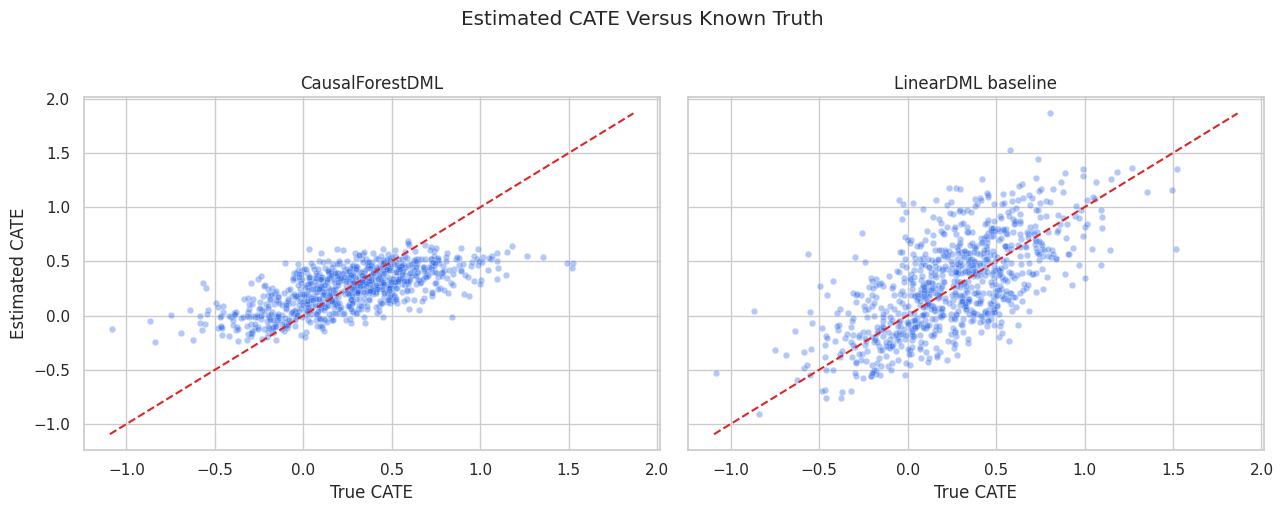

In [19]:
cate_plot_df = pd.concat(
    [
        pd.DataFrame({"true_cate": true_cate_test, "estimated_cate": linear_cate_test, "estimator": "LinearDML baseline"}),
        pd.DataFrame({"true_cate": true_cate_test, "estimated_cate": forest_cate_test, "estimator": "CausalForestDML"}),
    ],
    ignore_index=True,
)
limits = [
    min(cate_plot_df["true_cate"].min(), cate_plot_df["estimated_cate"].min()),
    max(cate_plot_df["true_cate"].max(), cate_plot_df["estimated_cate"].max()),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
for ax, (estimator_name, estimator_df) in zip(axes, cate_plot_df.groupby("estimator")):
    sample_df = estimator_df.sample(n=min(850, len(estimator_df)), random_state=RANDOM_SEED)
    sns.scatterplot(data=sample_df, x="true_cate", y="estimated_cate", alpha=0.35, s=22, color="#2563eb", ax=ax)
    ax.plot(limits, limits, color="#dc2626", linestyle="--", linewidth=1.5)
    ax.set_title(estimator_name)
    ax.set_xlabel("True CATE")
    ax.set_ylabel("Estimated CATE")

plt.suptitle("Estimated CATE Versus Known Truth", y=1.02)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "04_cate_recovery_scatter.png", dpi=160, bbox_inches="tight")
plt.show()

What this shows: the forest has room to learn curved patterns that the linear baseline compresses. The scatter is still noisy because treatment-effect estimation is harder than outcome prediction.

## Causal Forest Feature Importance

`feature_importances_` summarizes which `X` features the forest uses most when splitting the CATE surface.

This is not proof of causality. Feature importance is a model diagnostic: it helps explain what the fitted forest relied on, assuming the causal design is already reasonable.

In [20]:
forest_importance = pd.DataFrame(
    {
        "feature": effect_modifier_cols,
        "importance": np.ravel(causal_forest.feature_importances_),
        "true_cate_driver": [col in true_driver_cols for col in effect_modifier_cols],
    }
).sort_values("importance", ascending=False)

forest_importance.to_csv(TABLE_DIR / "04_causal_forest_feature_importance.csv", index=False)
display(forest_importance)

,feature,importance,true_cate_driver
2,friction_score,0.4603,True
0,baseline_need,0.1864,True
3,novelty_affinity,0.1345,True
5,content_depth,0.1089,True
4,price_sensitivity,0.0516,True
6,recency_gap,0.0287,False
1,prior_engagement,0.0219,True
7,region_risk,0.0066,True
8,high_need_segment,0.0011,True


What this shows: high-importance features are the dimensions the forest used most to partition treatment effects. A low-importance feature may still matter in a narrow region, but the table is a useful first summary.

## Feature Importance Plot

The plot makes the importance ranking easier to scan and highlights whether the forest is emphasizing true CATE drivers in the simulation.

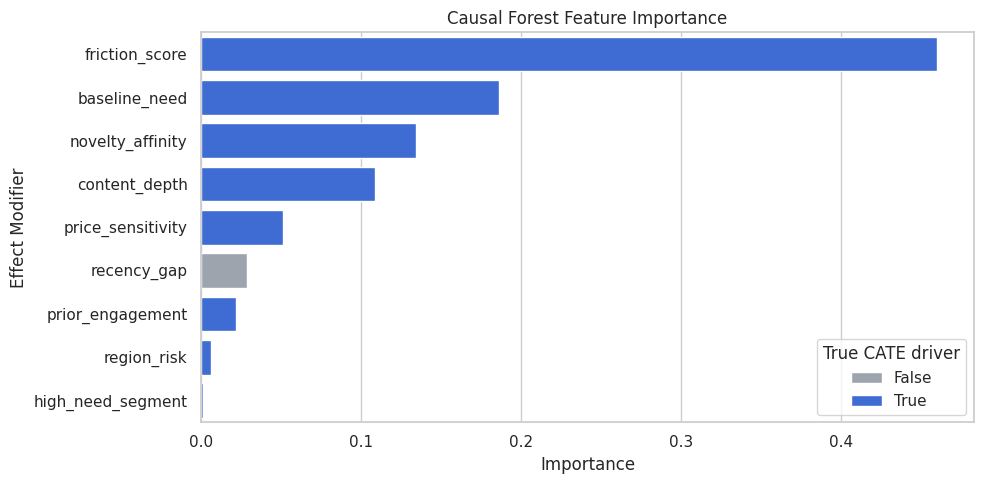

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=forest_importance,
    x="importance",
    y="feature",
    hue="true_cate_driver",
    dodge=False,
    palette={True: "#2563eb", False: "#9ca3af"},
    ax=ax,
)
ax.set_title("Causal Forest Feature Importance")
ax.set_xlabel("Importance")
ax.set_ylabel("Effect Modifier")
ax.legend(title="True CATE driver")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "04_causal_forest_feature_importance.png", dpi=160, bbox_inches="tight")
plt.show()

What this shows: feature importance helps turn a flexible forest into a readable summary. It should be paired with segment and calibration checks rather than read alone.

## CATE Decile Calibration

CATE models are often used to rank units. The next table groups test rows into predicted CATE deciles and compares estimated and true average CATE.

In [22]:
test_results = test_df.assign(
    linear_cate=linear_cate_test,
    forest_cate=forest_cate_test,
    forest_ci_lower=forest_lower_test,
    forest_ci_upper=forest_upper_test,
    forest_ci_width=forest_upper_test - forest_lower_test,
)

calibration_frames = []
for estimator_name, score_col in [("LinearDML baseline", "linear_cate"), ("CausalForestDML", "forest_cate")]:
    temp = test_results.copy()
    temp["cate_decile"] = pd.qcut(temp[score_col], q=10, labels=False, duplicates="drop") + 1
    deciles = (
        temp.groupby("cate_decile", observed=True)
        .agg(
            rows=("outcome", "size"),
            estimated_cate=(score_col, "mean"),
            true_cate=("true_cate", "mean"),
            treatment_rate=("treatment", "mean"),
            propensity_mean=("propensity", "mean"),
        )
        .reset_index()
    )
    deciles["estimator"] = estimator_name
    calibration_frames.append(deciles)

cate_decile_calibration = pd.concat(calibration_frames, ignore_index=True)
cate_decile_calibration.to_csv(TABLE_DIR / "04_cate_decile_calibration.csv", index=False)
display(cate_decile_calibration)

,cate_decile,rows,estimated_cate,true_cate,treatment_rate,propensity_mean,estimator
0,1,105,-0.4223,-0.1913,0.4476,0.4518,LinearDML baseline
1,2,105,-0.1684,-0.0217,0.5524,0.4978,LinearDML baseline
2,3,105,-0.0197,0.1252,0.5048,0.4691,LinearDML baseline
3,4,105,0.1049,0.2013,0.4667,0.4512,LinearDML baseline
4,5,105,0.2207,0.2409,0.4857,0.4605,LinearDML baseline
5,6,105,0.3453,0.3092,0.5429,0.5033,LinearDML baseline
6,7,105,0.4727,0.3315,0.4476,0.4962,LinearDML baseline
7,8,105,0.6045,0.4560,0.5333,0.5539,LinearDML baseline
8,9,105,0.7702,0.5105,0.4381,0.4927,LinearDML baseline
9,10,105,1.0838,0.6319,0.6000,0.5914,LinearDML baseline


What this shows: if predicted CATE ranking is useful, higher predicted deciles should also have higher true CATE in this simulation. This is one of the most practical checks for treatment targeting.

## CATE Decile Calibration Plot

The plot compares estimated and true average CATE by predicted-effect decile for both models.

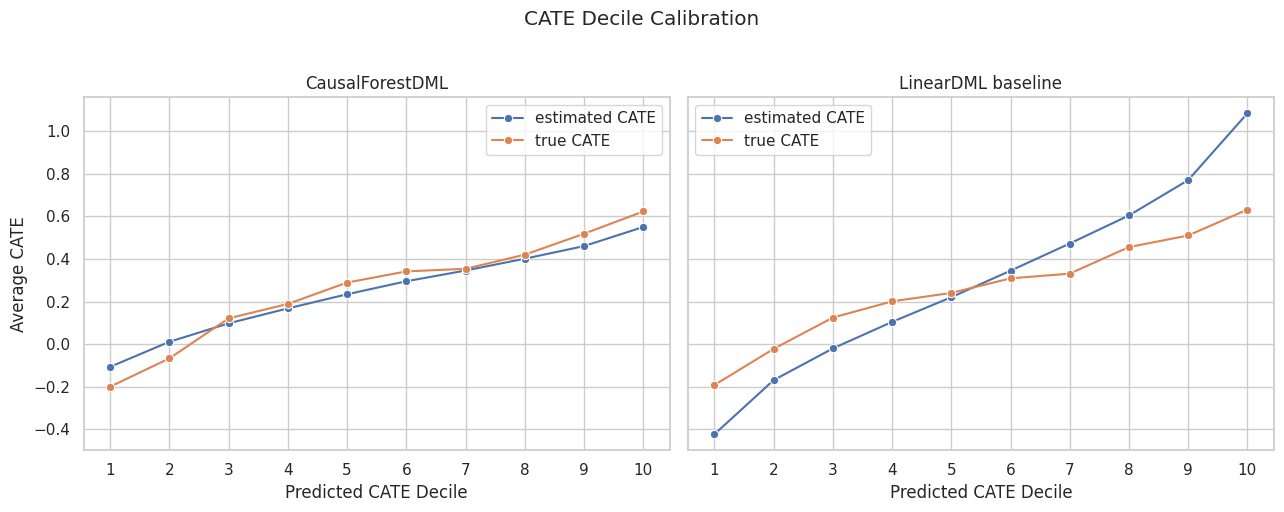

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, (estimator_name, estimator_df) in zip(axes, cate_decile_calibration.groupby("estimator")):
    sns.lineplot(data=estimator_df, x="cate_decile", y="estimated_cate", marker="o", label="estimated CATE", ax=ax)
    sns.lineplot(data=estimator_df, x="cate_decile", y="true_cate", marker="o", label="true CATE", ax=ax)
    ax.set_title(estimator_name)
    ax.set_xlabel("Predicted CATE Decile")
    ax.set_ylabel("Average CATE")
    ax.set_xticks(sorted(estimator_df["cate_decile"].unique()))

plt.suptitle("CATE Decile Calibration", y=1.02)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "04_cate_decile_calibration.png", dpi=160, bbox_inches="tight")
plt.show()

What this shows: decile calibration connects model output to decision-making. The forest is valuable if its ranking separates higher-benefit and lower-benefit rows more clearly.

## Segment-Level CATE Recovery

Segment summaries are useful when a forest is too flexible to explain with coefficients. Here we summarize by high-need segment and region risk.

In [24]:
segment_summary = (
    test_results.groupby(["high_need_segment", "region_risk"], observed=True)
    .agg(
        rows=("outcome", "size"),
        true_cate=("true_cate", "mean"),
        linear_cate=("linear_cate", "mean"),
        forest_cate=("forest_cate", "mean"),
        forest_ci_width=("forest_ci_width", "mean"),
        treatment_rate=("treatment", "mean"),
        propensity_mean=("propensity", "mean"),
    )
    .reset_index()
)
segment_summary["linear_error"] = segment_summary["linear_cate"] - segment_summary["true_cate"]
segment_summary["forest_error"] = segment_summary["forest_cate"] - segment_summary["true_cate"]

segment_summary.to_csv(TABLE_DIR / "04_segment_cate_recovery.csv", index=False)
display(segment_summary)

,high_need_segment,region_risk,rows,true_cate,linear_cate,forest_cate,forest_ci_width,treatment_rate,propensity_mean,linear_error,forest_error
0,0,0,506,0.2593,0.1841,0.2465,0.5553,0.3992,0.3902,-0.0752,-0.0129
1,0,1,258,0.0822,0.2057,0.2239,0.5415,0.4496,0.4401,0.1236,0.1418
2,1,0,167,0.5164,0.5902,0.2712,0.6407,0.7126,0.7144,0.0738,-0.2453
3,1,1,119,0.2829,0.5825,0.2576,0.6209,0.7563,0.7675,0.2996,-0.0253


What this shows: segment summaries make flexible CATE estimates more communicable. The interval-width column also shows whether some segments are estimated with more uncertainty than others.

## Segment Recovery Plot

This plot compares true and estimated segment-level effects.

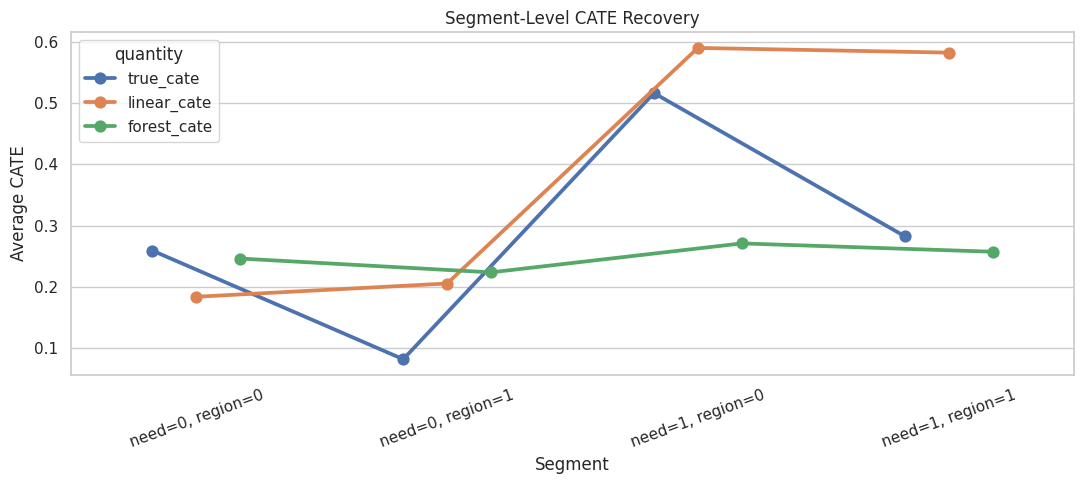

In [25]:
segment_plot_df = segment_summary.melt(
    id_vars=["high_need_segment", "region_risk", "rows"],
    value_vars=["true_cate", "linear_cate", "forest_cate"],
    var_name="quantity",
    value_name="average_cate",
)
segment_plot_df["segment"] = (
    "need=" + segment_plot_df["high_need_segment"].astype(str)
    + ", region=" + segment_plot_df["region_risk"].astype(str)
)

fig, ax = plt.subplots(figsize=(11, 5))
sns.pointplot(
    data=segment_plot_df,
    x="segment",
    y="average_cate",
    hue="quantity",
    dodge=0.35,
    errorbar=None,
    ax=ax,
)
ax.set_title("Segment-Level CATE Recovery")
ax.set_xlabel("Segment")
ax.set_ylabel("Average CATE")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "04_segment_cate_recovery.png", dpi=160, bbox_inches="tight")
plt.show()

What this shows: the forest can be summarized at the segment level even though it estimates effects continuously over `X`. This is often the easiest way to explain results to non-modeling audiences.

## Nonlinear Effect Slice: Baseline Need

A causal forest can learn nonlinear effect variation. To visualize that, we group rows by quantiles of `baseline_need` and compare true and estimated average CATE.

In [26]:
need_slice = test_results.assign(
    baseline_need_bucket=pd.qcut(test_results["baseline_need"], q=8, duplicates="drop")
)
need_slice_summary = (
    need_slice.groupby("baseline_need_bucket", observed=True)
    .agg(
        rows=("outcome", "size"),
        baseline_need_mean=("baseline_need", "mean"),
        true_cate=("true_cate", "mean"),
        linear_cate=("linear_cate", "mean"),
        forest_cate=("forest_cate", "mean"),
        forest_ci_width=("forest_ci_width", "mean"),
    )
    .reset_index(drop=True)
)
need_slice_summary["bucket_id"] = np.arange(1, len(need_slice_summary) + 1)

need_slice_summary.to_csv(TABLE_DIR / "04_baseline_need_effect_slice.csv", index=False)
display(need_slice_summary)

,rows,baseline_need_mean,true_cate,linear_cate,forest_cate,forest_ci_width,bucket_id
0,132,-1.6839,0.2317,0.3111,0.2726,0.5752,1
1,131,-0.9749,0.2242,0.2104,0.2260,0.5954,2
2,131,-0.5783,0.2334,0.2385,0.2590,0.5326,3
3,131,-0.1874,0.1450,0.0729,0.2150,0.5397,4
4,131,0.1386,0.1997,0.1761,0.2409,0.5330,5
5,131,0.4924,0.1987,0.2186,0.2203,0.5386,6
6,131,0.8488,0.4372,0.6159,0.2459,0.6448,7
7,132,1.5653,0.4042,0.5480,0.2887,0.6239,8


What this shows: slicing by an important modifier lets us inspect the shape of heterogeneity. Because the true CATE has a threshold component in baseline need, a forest should track a nonlinear bend better than a simple linear final stage.

## Baseline Need Slice Plot

This plot shows how average treatment effect changes across baseline-need buckets.

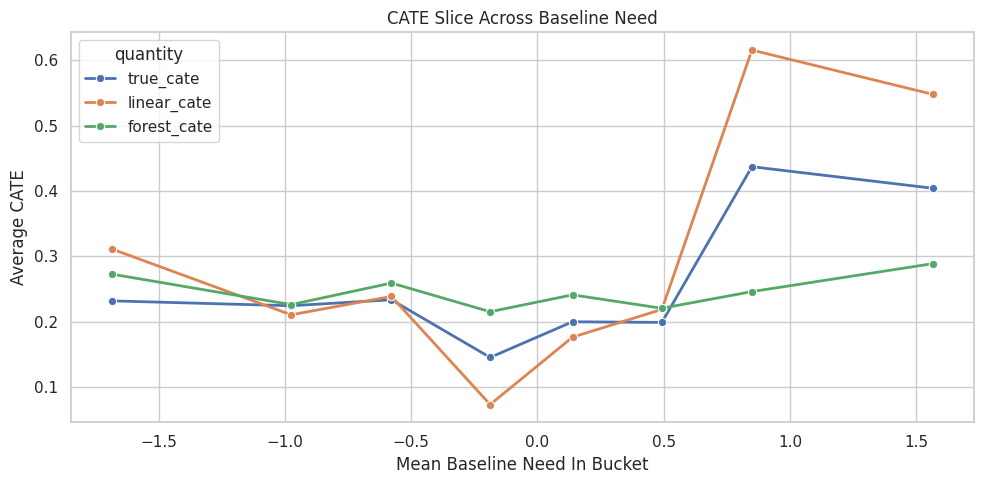

In [27]:
need_plot_df = need_slice_summary.melt(
    id_vars=["bucket_id", "baseline_need_mean", "rows"],
    value_vars=["true_cate", "linear_cate", "forest_cate"],
    var_name="quantity",
    value_name="average_cate",
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=need_plot_df, x="baseline_need_mean", y="average_cate", hue="quantity", marker="o", linewidth=2, ax=ax)
ax.set_title("CATE Slice Across Baseline Need")
ax.set_xlabel("Mean Baseline Need In Bucket")
ax.set_ylabel("Average CATE")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "04_baseline_need_effect_slice.png", dpi=160, bbox_inches="tight")
plt.show()

What this shows: effect-slice plots are a practical way to explain nonlinear CATE patterns without opening the full forest internals.

## Nonlinear Effect Slice: Friction Score

The true CATE has a stronger penalty when friction is positive. A friction slice checks whether the forest detects that asymmetric shape.

In [28]:
friction_slice = test_results.assign(
    friction_bucket=pd.qcut(test_results["friction_score"], q=8, duplicates="drop")
)
friction_slice_summary = (
    friction_slice.groupby("friction_bucket", observed=True)
    .agg(
        rows=("outcome", "size"),
        friction_score_mean=("friction_score", "mean"),
        true_cate=("true_cate", "mean"),
        linear_cate=("linear_cate", "mean"),
        forest_cate=("forest_cate", "mean"),
        forest_ci_width=("forest_ci_width", "mean"),
    )
    .reset_index(drop=True)
)
friction_slice_summary["bucket_id"] = np.arange(1, len(friction_slice_summary) + 1)

friction_slice_summary.to_csv(TABLE_DIR / "04_friction_effect_slice.csv", index=False)
display(friction_slice_summary)

,rows,friction_score_mean,true_cate,linear_cate,forest_cate,forest_ci_width,bucket_id
0,132,-1.7714,0.3769,0.7748,0.4713,0.5347,1
1,131,-0.9498,0.3600,0.5349,0.3991,0.5532,2
2,131,-0.5066,0.3872,0.4239,0.3516,0.5662,3
3,131,-0.1412,0.3727,0.3492,0.2935,0.5252,4
4,131,0.2025,0.3243,0.2215,0.2262,0.5893,5
5,131,0.5432,0.2200,0.1273,0.1403,0.5920,6
6,131,0.8945,0.0631,0.0184,0.0719,0.5954,7
7,132,1.6211,-0.0281,-0.0576,0.0150,0.6275,8


What this shows: this table checks whether estimated effects drop as friction increases. The forest is expected to capture this shape more naturally than a linear model.

## Friction Slice Plot

The friction plot shows estimated and true average CATE across friction buckets.

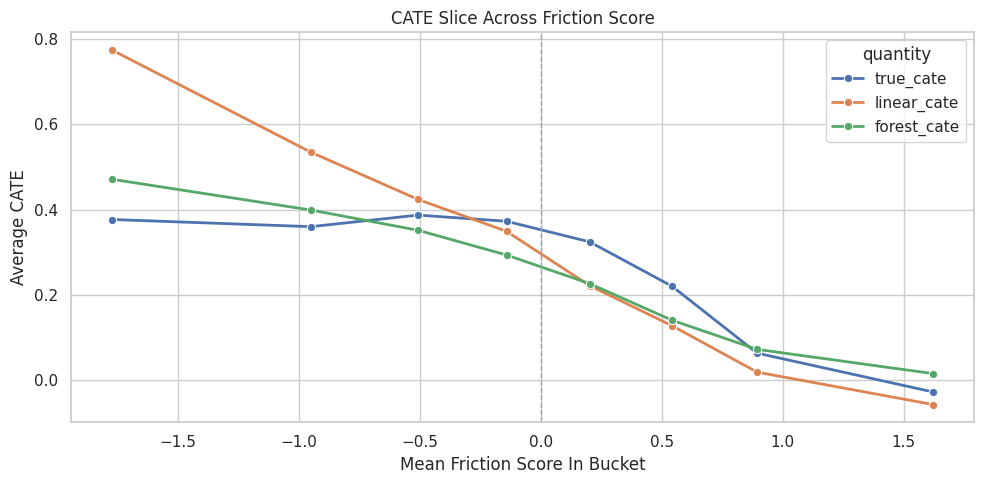

In [29]:
friction_plot_df = friction_slice_summary.melt(
    id_vars=["bucket_id", "friction_score_mean", "rows"],
    value_vars=["true_cate", "linear_cate", "forest_cate"],
    var_name="quantity",
    value_name="average_cate",
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=friction_plot_df, x="friction_score_mean", y="average_cate", hue="quantity", marker="o", linewidth=2, ax=ax)
ax.axvline(0, color="#9ca3af", linestyle="--", linewidth=1)
ax.set_title("CATE Slice Across Friction Score")
ax.set_xlabel("Mean Friction Score In Bucket")
ax.set_ylabel("Average CATE")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "04_friction_effect_slice.png", dpi=160, bbox_inches="tight")
plt.show()

What this shows: the vertical zero line marks where the true friction penalty begins to behave differently. This is the kind of shape a forest can learn without manual feature engineering.

## Uncertainty Interval Summary

Causal forests can produce unit-level effect intervals. The next cell summarizes interval width and simple truth-known coverage.

Coverage is available only because this is simulated data. In real data, interval width is still useful as a rough uncertainty diagnostic.

In [30]:
interval_summary = pd.DataFrame(
    [
        {"metric": "mean_interval_width", "value": test_results["forest_ci_width"].mean()},
        {"metric": "median_interval_width", "value": test_results["forest_ci_width"].median()},
        {"metric": "p90_interval_width", "value": test_results["forest_ci_width"].quantile(0.90)},
        {"metric": "share_intervals_cover_true_cate", "value": ((test_results["true_cate"] >= test_results["forest_ci_lower"]) & (test_results["true_cate"] <= test_results["forest_ci_upper"])).mean()},
        {"metric": "share_intervals_entirely_positive", "value": (test_results["forest_ci_lower"] > 0).mean()},
        {"metric": "share_point_estimates_positive", "value": (test_results["forest_cate"] > 0).mean()},
    ]
)

interval_summary.to_csv(TABLE_DIR / "04_interval_summary.csv", index=False)
display(interval_summary)

,metric,value
0,mean_interval_width,0.5730
1,median_interval_width,0.5525
2,p90_interval_width,0.8086
3,share_intervals_cover_true_cate,0.6981
4,share_intervals_entirely_positive,0.4695
5,share_point_estimates_positive,0.8638


What this shows: point estimates and uncertainty intervals answer different questions. A positive point estimate may still have an interval that crosses zero, especially in weak-support or noisy regions.

## Interval Width Drivers

Intervals tend to widen when the model has less local information. The next cell relates interval width to propensity, treatment status, and key features.

In [31]:
width_analysis = test_results.assign(
    propensity_extremeness=(test_results["propensity"] - 0.5).abs(),
    absolute_baseline_need=test_results["baseline_need"].abs(),
    absolute_friction=test_results["friction_score"].abs(),
)

width_correlations = pd.DataFrame(
    [
        {"quantity": col, "correlation_with_interval_width": width_analysis["forest_ci_width"].corr(width_analysis[col])}
        for col in ["propensity_extremeness", "absolute_baseline_need", "absolute_friction", "content_depth", "recency_gap"]
    ]
).sort_values("correlation_with_interval_width", key=lambda s: s.abs(), ascending=False)

width_correlations.to_csv(TABLE_DIR / "04_interval_width_correlations.csv", index=False)
display(width_correlations)

,quantity,correlation_with_interval_width
1,absolute_baseline_need,0.1732
0,propensity_extremeness,0.1457
3,content_depth,-0.0713
2,absolute_friction,0.0282
4,recency_gap,-0.0004


What this shows: interval width can be used as a support diagnostic. Stronger width in extreme propensity or feature regions suggests the forest is less certain where comparable examples are thinner.

## Interval Width Plot

The scatter plot shows how interval width changes with propensity extremeness. Extreme propensity values often mean fewer comparable treated and untreated observations.

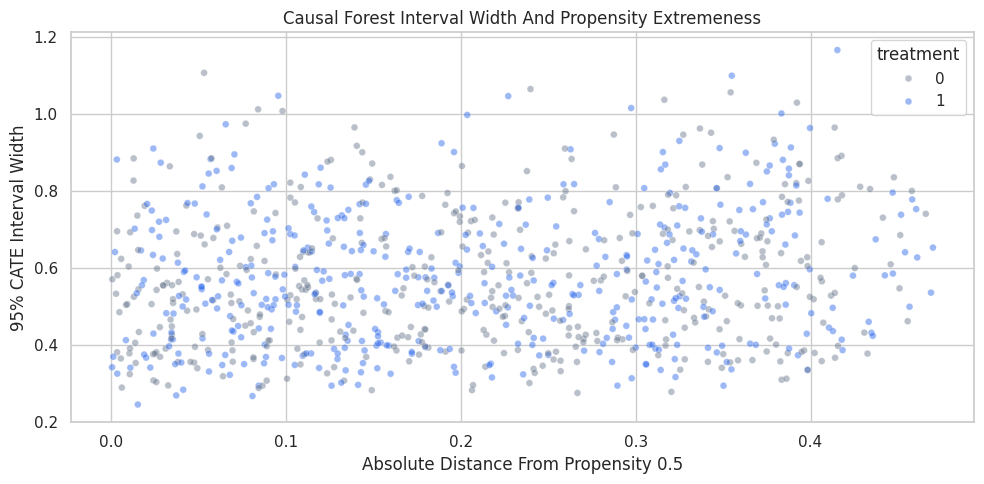

In [32]:
plot_width_sample = width_analysis.sample(n=min(900, len(width_analysis)), random_state=RANDOM_SEED)

fig, ax = plt.subplots(figsize=(10, 5))
sns.scatterplot(
    data=plot_width_sample,
    x="propensity_extremeness",
    y="forest_ci_width",
    hue="treatment",
    alpha=0.45,
    s=24,
    palette={0: "#64748b", 1: "#2563eb"},
    ax=ax,
)
ax.set_title("Causal Forest Interval Width And Propensity Extremeness")
ax.set_xlabel("Absolute Distance From Propensity 0.5")
ax.set_ylabel("95% CATE Interval Width")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "04_interval_width_by_propensity.png", dpi=160, bbox_inches="tight")
plt.show()

What this shows: uncertainty is not evenly distributed. When using CATE estimates for decisions, high predicted benefit should be weighed against uncertainty and support.

## Targeting Comparison

A common use for CATE estimates is selecting a top fraction of units for treatment. The next cell compares random targeting, linear-DML targeting, causal-forest targeting, and an oracle benchmark.

In [33]:
targeting_fraction = 0.20
k = int(np.ceil(targeting_fraction * len(test_results)))
random_selected = test_results.sample(n=k, random_state=RANDOM_SEED).index
linear_selected = test_results.sort_values("linear_cate", ascending=False).head(k).index
forest_selected = test_results.sort_values("forest_cate", ascending=False).head(k).index
forest_confident_selected = test_results.sort_values("forest_ci_lower", ascending=False).head(k).index
oracle_selected = test_results.sort_values("true_cate", ascending=False).head(k).index

targeting_rows = []
for rule_name, selected_index in [
    ("random 20 percent", random_selected),
    ("top 20 percent by LinearDML", linear_selected),
    ("top 20 percent by CausalForestDML point estimate", forest_selected),
    ("top 20 percent by CausalForestDML lower interval", forest_confident_selected),
    ("oracle top 20 percent by true CATE", oracle_selected),
]:
    selected = test_results.loc[selected_index]
    targeting_rows.append(
        {
            "targeting_rule": rule_name,
            "selected_rows": len(selected),
            "average_true_cate_in_selected_group": selected["true_cate"].mean(),
            "average_estimated_forest_cate": selected["forest_cate"].mean(),
            "average_forest_interval_width": selected["forest_ci_width"].mean(),
            "share_high_need_segment": selected["high_need_segment"].mean(),
            "average_propensity": selected["propensity"].mean(),
        }
    )

targeting_summary = pd.DataFrame(targeting_rows)
targeting_summary["gain_vs_random_true_cate"] = (
    targeting_summary["average_true_cate_in_selected_group"]
    - targeting_summary.loc[targeting_summary["targeting_rule"].eq("random 20 percent"), "average_true_cate_in_selected_group"].iloc[0]
)

targeting_summary.to_csv(TABLE_DIR / "04_targeting_summary.csv", index=False)
display(targeting_summary)

,targeting_rule,selected_rows,average_true_cate_in_selected_group,average_estimated_forest_cate,average_forest_interval_width,share_high_need_segment,average_propensity,gain_vs_random_true_cate
0,random 20 percent,210,0.2731,0.2449,0.5645,0.2762,0.5330,0.0000
1,top 20 percent by LinearDML,210,0.5712,0.4598,0.5787,0.5619,0.5420,0.2981
2,top 20 percent by CausalForestDML point estimate,210,0.5709,0.5054,0.5291,0.2714,0.4980,0.2978
3,top 20 percent by CausalForestDML lower interval,210,0.5412,0.4903,0.4596,0.2143,0.5104,0.2682
4,oracle top 20 percent by true CATE,210,0.7570,0.4105,0.5611,0.5381,0.6570,0.4839


What this shows: targeting by point estimate and targeting by lower interval can choose different units. The lower-interval rule is more conservative because it rewards high estimated benefit and lower uncertainty.

## Targeting Plot

The plot compares true average benefit among selected rows under each targeting rule.

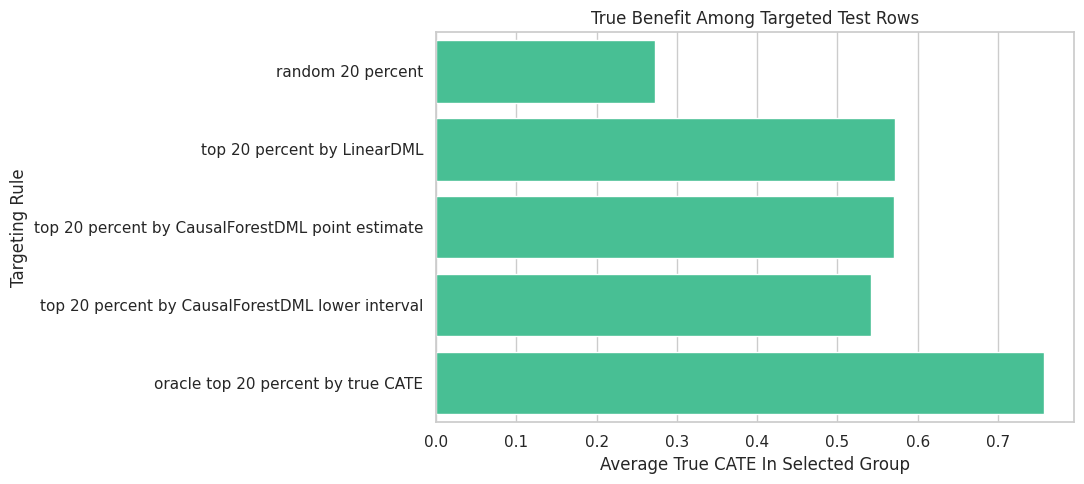

In [34]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(
    data=targeting_summary,
    x="average_true_cate_in_selected_group",
    y="targeting_rule",
    color="#34d399",
    ax=ax,
)
ax.set_title("True Benefit Among Targeted Test Rows")
ax.set_xlabel("Average True CATE In Selected Group")
ax.set_ylabel("Targeting Rule")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "04_targeting_summary.png", dpi=160, bbox_inches="tight")
plt.show()

What this shows: model quality becomes operational in targeting. A good CATE model identifies a selected group with higher true benefit than random selection.

## Support-Aware CATE Table

The next table bins rows by estimated CATE and interval width. This helps separate high estimated benefit from high estimated benefit with high uncertainty.

In [35]:
support_table = test_results.assign(
    forest_cate_bucket=pd.qcut(test_results["forest_cate"], q=4, labels=["lowest", "low-mid", "high-mid", "highest"], duplicates="drop"),
    width_bucket=pd.qcut(test_results["forest_ci_width"], q=4, labels=["narrow", "mid-narrow", "mid-wide", "wide"], duplicates="drop"),
)

support_summary = (
    support_table.groupby(["forest_cate_bucket", "width_bucket"], observed=True)
    .agg(
        rows=("outcome", "size"),
        true_cate=("true_cate", "mean"),
        forest_cate=("forest_cate", "mean"),
        forest_ci_width=("forest_ci_width", "mean"),
        propensity_mean=("propensity", "mean"),
    )
    .reset_index()
)

support_summary.to_csv(TABLE_DIR / "04_support_aware_cate_summary.csv", index=False)
display(support_summary)

,forest_cate_bucket,width_bucket,rows,true_cate,forest_cate,forest_ci_width,propensity_mean
0,lowest,narrow,57,-0.1151,-0.0096,0.3810,0.4764
1,lowest,mid-narrow,58,-0.1070,-0.0268,0.4934,0.5112
2,lowest,mid-wide,76,-0.1475,-0.0358,0.6103,0.4829
3,lowest,wide,72,0.0141,-0.0120,0.8068,0.5483
4,low-mid,narrow,63,0.2168,0.1938,0.3715,0.4647
5,low-mid,mid-narrow,55,0.1946,0.1781,0.5083,0.4999
6,low-mid,mid-wide,51,0.2216,0.1894,0.6217,0.5013
7,low-mid,wide,93,0.2421,0.1803,0.8030,0.5281
8,high-mid,narrow,68,0.3752,0.3386,0.3692,0.4666
9,high-mid,mid-narrow,71,0.3447,0.3295,0.4927,0.4474


What this shows: a high point estimate is more persuasive when the interval is not extremely wide. This support-aware view is useful when deciding whether to act on CATE estimates.

## Practical Causal Forest Guidance

This table summarizes when a causal forest is a good choice and what to watch carefully.

In [36]:
practical_guidance = pd.DataFrame(
    [
        {
            "situation": "Expected heterogeneity is nonlinear or interaction-heavy",
            "why CausalForestDML helps": "The forest can split on feature regions without manually specifying every interaction.",
            "watchout": "Use slices and segment summaries to keep the result explainable.",
        },
        {
            "situation": "The main goal is treatment targeting",
            "why CausalForestDML helps": "Ranking quality can improve when the true CATE surface is nonlinear.",
            "watchout": "Evaluate targeting with policy checks, experiments, or simulation truth when available.",
        },
        {
            "situation": "There are weak-overlap regions",
            "why CausalForestDML helps": "Intervals and local estimates can reveal uncertainty.",
            "watchout": "Avoid overusing estimates in unsupported regions.",
        },
        {
            "situation": "A simple coefficient narrative is required",
            "why CausalForestDML helps": "Feature importance and slices can still explain broad patterns.",
            "watchout": "A linear DML model may be easier to communicate if performance is similar.",
        },
    ]
)

practical_guidance.to_csv(TABLE_DIR / "04_practical_guidance.csv", index=False)
display(practical_guidance)

,situation,why CausalForestDML helps,watchout
0,Expected heterogeneity is nonlinear or interac...,The forest can split on feature regions withou...,Use slices and segment summaries to keep the r...
1,The main goal is treatment targeting,Ranking quality can improve when the true CATE...,"Evaluate targeting with policy checks, experim..."
2,There are weak-overlap regions,Intervals and local estimates can reveal uncer...,Avoid overusing estimates in unsupported regions.
3,A simple coefficient narrative is required,Feature importance and slices can still explai...,A linear DML model may be easier to communicat...


What this shows: `CausalForestDML` is most compelling when flexibility improves the decision problem. If a simpler model performs similarly, the simpler model may be preferable.

## Causal Forest Checklist

Before presenting a causal forest estimate, it is worth checking the items below.

In [37]:
forest_checklist = pd.DataFrame(
    [
        {"check": "Treatment and outcome are clearly defined", "why_it_matters": "The forest estimates the effect of a specific intervention."},
        {"check": "All X and W features are pre-treatment", "why_it_matters": "Post-treatment controls can distort the causal estimand."},
        {"check": "X contains meaningful heterogeneity dimensions", "why_it_matters": "The forest splits over X to estimate CATE variation."},
        {"check": "W contains important confounding controls", "why_it_matters": "Nuisance models need enough information to adjust treatment and outcome structure."},
        {"check": "Overlap is adequate", "why_it_matters": "Local treatment-effect estimates need comparable treated and untreated units."},
        {"check": "Nuisance models are reasonable", "why_it_matters": "Poor nuisance models leave confounding in the final CATE stage."},
        {"check": "Feature importance and slices make sense", "why_it_matters": "Flexible models need readable summaries."},
        {"check": "Interval widths are inspected", "why_it_matters": "Wide intervals flag uncertain regions."},
        {"check": "Targeting is evaluated with uncertainty in mind", "why_it_matters": "High point estimates can be fragile when support is weak."},
    ]
)

forest_checklist.to_csv(TABLE_DIR / "04_causal_forest_checklist.csv", index=False)
display(forest_checklist)

,check,why_it_matters
0,Treatment and outcome are clearly defined,The forest estimates the effect of a specific ...
1,All X and W features are pre-treatment,Post-treatment controls can distort the causal...
2,X contains meaningful heterogeneity dimensions,The forest splits over X to estimate CATE vari...
3,W contains important confounding controls,Nuisance models need enough information to adj...
4,Overlap is adequate,Local treatment-effect estimates need comparab...
5,Nuisance models are reasonable,Poor nuisance models leave confounding in the ...
6,Feature importance and slices make sense,Flexible models need readable summaries.
7,Interval widths are inspected,Wide intervals flag uncertain regions.
8,Targeting is evaluated with uncertainty in mind,High point estimates can be fragile when suppo...


What this shows: causal forests are powerful, but the analysis is only credible when model output is paired with design checks, support checks, and uncertainty-aware reporting.

## Summary

This notebook introduced `CausalForestDML` as a flexible DML estimator for nonlinear heterogeneous treatment effects.

The main takeaways are:

- causal forests estimate a flexible CATE surface over `X`;
- nuisance models still handle outcome and treatment adjustment;
- feature importance helps explain what the fitted forest used;
- effect intervals help distinguish high estimated benefit from high confidence;
- segment summaries and effect slices make forest estimates easier to communicate;
- CATE deciles and targeting tables connect estimation to action;
- causal forests are most useful when they improve heterogeneity recovery or targeting over simpler linear models.

The next tutorial can move to `DRLearner`, where the focus shifts from forest-style local treatment effects to doubly robust pseudo-outcomes for binary treatment settings.